In [1]:
# ======================================
# 🧠 Resume Training for GTSRB Model
# ======================================

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tqdm import tqdm



In [2]:
# -------------------------------
# Paths and Constants
# -------------------------------
DATA_DIR = "./data"
TRAIN_CSV = os.path.join(DATA_DIR, "Train.csv")
TEST_CSV = os.path.join(DATA_DIR, "Test.csv")
MODEL_PATH = "./models/traffic_sign_detection_gtsrb.h5"
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
EPOCHS = 12
NUM_CLASSES = 43

# -------------------------------
# Load CSV Data
# -------------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"✅ Train samples: {len(train_df)}, Test samples: {len(test_df)}")

# -------------------------------
# Preprocessing Function
# -------------------------------
def preprocess_images(df, base_dir):
    images = []
    labels = []

    for i in tqdm(range(df.shape[0]), desc=f"Loading images from {base_dir}"):
        img_path = os.path.join(base_dir, df['Path'].iloc[i])
        label = df['ClassId'].iloc[i]
        try:
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img = image.img_to_array(img)
            img = img / 255.0
            images.append(img)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Error loading image {img_path}: {e}")

    X = np.array(images)
    y = to_categorical(np.array(labels), NUM_CLASSES)
    return X, y

# -------------------------------
# Load Train and Validation Data
# -------------------------------
X_train_full, y_train_full = preprocess_images(train_df, os.path.join(DATA_DIR))
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")



✅ Train samples: 39209, Test samples: 12630


Loading images from ./data: 100%|██████████| 39209/39209 [00:45<00:00, 863.69it/s] 


Train shape: (31367, 32, 32, 3), Validation shape: (7842, 32, 32, 3)


In [3]:
# -------------------------------
# Load Existing Model
# -------------------------------
if os.path.exists(MODEL_PATH):
    print("✅ Loading saved model...")
    tf.config.run_functions_eagerly(True)
    model = load_model(MODEL_PATH)
else:
    raise FileNotFoundError(f"❌ Saved model not found at {MODEL_PATH}")

# -------------------------------
# Data Augmentation
# -------------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

# -------------------------------
# Callbacks
# -------------------------------
checkpoint_path = "./models/traffic_sign_detection_gtsrb_resume.h5"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)
]



d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Loading saved model...


In [4]:
# -------------------------------
# Resume Training
# -------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(),   # new optimizer instance
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------
# Save Updated Model
# -------------------------------
model.save("./models/exp_traffic_sign_detection_gtsrb_updated.h5")
print("✅ Training resumed and updated model saved at './models/traffic_sign_detection_gtsrb_updated.h5'")



Epoch 1/12


d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7490 - loss: 1.1209
Epoch 1: val_accuracy improved from None to 0.99324, saving model to ./models/traffic_sign_detection_gtsrb_resume.h5


491/491 ━━━━━━━━━━━━━━━━━━━━ 67s 135ms/step - accuracy: 0.7991 - loss: 0.7829 - val_accuracy: 0.9932 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 2/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8769 - loss: 0.4284
Epoch 2: val_accuracy improved from 0.99324 to 0.99554, saving model to ./models/traffic_sign_detection_gtsrb_resume.h5


491/491 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.8869 - loss: 0.3882 - val_accuracy: 0.9955 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 3/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9136 - loss: 0.3026
Epoch 3: val_accuracy did not improve from 0.99554
491/491 ━━━━━━━━━━━━━━━━━━━━ 60s 123ms/step - accuracy: 0.9192 - loss: 0.2787 - val_accuracy: 0.9934 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 4/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9326 - loss: 0.2257
Epoch 4: val_accuracy did not improve from 0.99554
491/491 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.9334 - loss: 0.2174 - val_accuracy: 0.9954 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 5/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9408 - loss: 0.1989
Epoch 5: val_accuracy improved from 0.99554 to 0.99566, saving model to ./models/traffic_sign_detection_gtsrb_resume.h5


491/491 ━━━━━━━━━━━━━━━━━━━━ 136s 278ms/step - accuracy: 0.9422 - loss: 0.1939 - val_accuracy: 0.9957 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 6/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9472 - loss: 0.1706
Epoch 6: val_accuracy did not improve from 0.99566
491/491 ━━━━━━━━━━━━━━━━━━━━ 165s 335ms/step - accuracy: 0.9492 - loss: 0.1657 - val_accuracy: 0.9957 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 7/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9532 - loss: 0.1593
Epoch 7: val_accuracy did not improve from 0.99566
491/491 ━━━━━━━━━━━━━━━━━━━━ 77s 156ms/step - accuracy: 0.9537 - loss: 0.1546 - val_accuracy: 0.9953 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 8/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9556 - loss: 0.1420
Epoch 8: val_accuracy improved from 0.99566 to 0.99643, saving model to ./models/traffic_sign_detection_gtsrb_resume.h5


491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.9569 - loss: 0.1449 - val_accuracy: 0.9964 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 9/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9655 - loss: 0.1167
Epoch 9: val_accuracy did not improve from 0.99643
491/491 ━━━━━━━━━━━━━━━━━━━━ 59s 120ms/step - accuracy: 0.9689 - loss: 0.1049 - val_accuracy: 0.9964 - val_loss: 0.0102 - learning_rate: 3.0000e-04
Epoch 10/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9733 - loss: 0.0925
Epoch 10: val_accuracy improved from 0.99643 to 0.99719, saving model to ./models/traffic_sign_detection_gtsrb_resume.h5


491/491 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.9719 - loss: 0.0964 - val_accuracy: 0.9972 - val_loss: 0.0091 - learning_rate: 3.0000e-04
Epoch 11/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9722 - loss: 0.0941
Epoch 11: val_accuracy did not improve from 0.99719
491/491 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - accuracy: 0.9725 - loss: 0.0910 - val_accuracy: 0.9972 - val_loss: 0.0082 - learning_rate: 3.0000e-04
Epoch 12/12
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9737 - loss: 0.0919
Epoch 12: val_accuracy did not improve from 0.99719
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 124ms/step - accuracy: 0.9733 - loss: 0.0919 - val_accuracy: 0.9971 - val_loss: 0.0079 - learning_rate: 3.0000e-04


✅ Training resumed and updated model saved at './models/traffic_sign_detection_gtsrb_updated.h5'


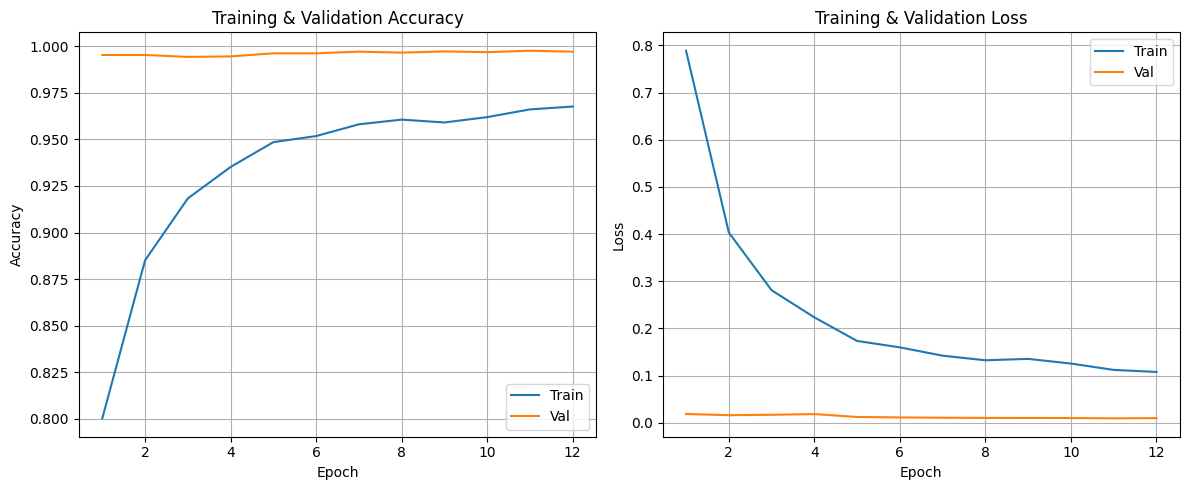

In [24]:
# ------------------ PASTE THIS CELL IMMEDIATELY AFTER:
# history = model.fit(...)

# Cell: Plot training & validation accuracy + loss (robust to key names)
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val(history, figsize=(12,5)):
    """
    Plots training & validation accuracy and loss from a Keras History object.
    Handles common key names like 'accuracy'/'acc' and 'val_accuracy'/'val_acc'.
    """
    hist = history.history if not isinstance(history, dict) else history

    # --- detect accuracy keys ---
    acc_key = None
    val_acc_key = None
    for k in hist.keys():
        kl = k.lower()
        if ('accuracy' in kl or kl.endswith('acc')) and not kl.startswith('val'):
            acc_key = k
        if ('val_accuracy' in kl or kl.startswith('val_') and ('accuracy' in kl or kl.endswith('acc'))):
            val_acc_key = k
    # fallback guesses
    if acc_key is None:
        for k in hist.keys():
            if 'acc' in k.lower() and not k.lower().startswith('val'):
                acc_key = k
    if val_acc_key is None and acc_key is not None:
        candidate = 'val_' + acc_key
        if candidate in hist:
            val_acc_key = candidate

    # --- detect loss keys ---
    loss_key = None
    val_loss_key = None
    for k in hist.keys():
        if 'loss' in k.lower() and not k.lower().startswith('val'):
            loss_key = k
        if k.lower().startswith('val_loss') or k.lower() == 'val_loss':
            val_loss_key = k
    if val_loss_key is None and loss_key is not None:
        candidate = 'val_' + loss_key
        if candidate in hist:
            val_loss_key = candidate

    # Determine number of epochs from any series length
    any_series = next(iter(hist.values()))
    epochs = np.arange(1, len(any_series) + 1)

    # Plot
    plt.figure(figsize=figsize)

    # Accuracy subplot
    plt.subplot(1,2,1)
    if acc_key and acc_key in hist:
        plt.plot(epochs, hist[acc_key], label='Train')
    if val_acc_key and val_acc_key in hist:
        plt.plot(epochs, hist[val_acc_key], label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss subplot
    plt.subplot(1,2,2)
    if loss_key and loss_key in hist:
        plt.plot(epochs, hist[loss_key], label='Train')
    if val_loss_key and val_loss_key in hist:
        plt.plot(epochs, hist[val_loss_key], label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage (assuming `history` is the returned History from model.fit)
plot_train_val(history)


In [21]:
# -------------------------------
# Evaluate on Test Data
# -------------------------------
X_test, y_test = preprocess_images(test_df, os.path.join(DATA_DIR))
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")


Loading images from ./data: 100%|██████████| 12630/12630 [00:06<00:00, 1998.13it/s]


395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9772 - loss: 0.1179
🎯 Test Accuracy: 97.72%


In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------
# Save Updated Model
# -------------------------------
model.save("./models/exp___________________traffic_sign_detection_gtsrb_updatedV2.h5")
print("✅ Training resumed and updated model saved at './models/traffic_sign_detection_gtsrb_updated.h5'")



Epoch 1/12
224/491 ━━━━━━━━━━━━━━━━━━━━ 37s 139ms/step - accuracy: 0.9676 - loss: 0.1139

KeyboardInterrupt: 

In [23]:
# -------------------------------
# Evaluate on Test Data
# -------------------------------
# X_test, y_test = preprocess_images(test_df, os.path.join(DATA_DIR))
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")


395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9787 - loss: 0.1146
🎯 Test Accuracy: 97.87%
